# ============================================================
# PROJECT 2: FRAUD DETECTION PIPELINE

# ============================================================

# 1. Core libraries

In [1]:

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, models, evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Imbalanced-learn: SMOTE + the leakage-safe pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 2. Load data

# References and Data Sources

 Credit Card Fraud Detection Dataset — Kaggle
  Machine Learning Group, Université Libre de Bruxelles (ULB)
  284,807 transactions, 492 fraud cases, 48-hour period
  https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [2]:
df= pd.read_csv("C:\\Users\\DELL User\\Desktop\\Decodelabs\\Kaggle creditcard data.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## 3. Exploratory Data Analysis

Before building any model, we need to understand the data we are working with. 
This section examines three things:
- The extreme class imbalance between legitimate and fraudulent transactions
- The distribution of the Amount feature — the only unscaled financial value
- The distribution of Time — a sequence marker spanning 48 hours of transactions


In [4]:
# Basic statistical summary of the two interpretable features — Amount and Time.
# V1-V28 are PCA components and carry no directly interpretable meaning,
# so we focus our EDA on the columns where raw values tell a real story.

df[['Amount', 'Time']].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


1. Amount ranges from $0 to $25,691 with a mean of $88 but a median of just $22 — a classic right-skewed distribution where most transactions are small. This extreme range is precisely why StandardScaler is non-negotiable for Logistic Regression — unscaled Amount would distort the regularization penalty.
2. Time spans 172,792 seconds (~48 hours) and simply counts seconds since the first transaction — it is a sequence marker, not a clock time.


In [5]:
# Structural overview of the dataset
# We expect 284,807 rows, 31 columns, zero missing values,
# and all float64 types except Class which is int64

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 3.3 Feature Analysis — Amount and Time

Of the 31 columns in this dataset, 28 (V1–V28) are anonymous Principal Componest Analysis components that carry no directly interpretable meaning. The only two features we can meaningfully explore in their raw form are Amount and Time.

We examine both features split by class to see whether fraud transactions cluster at particular amounts or times — early intuition about what patterns the model will learn to detect.

In [6]:
df.groupby('Class')[['Amount','Time']].describe().T 


Class                     0              1
Amount count  284315.000000     492.000000
       mean       88.291022     122.211321
       std       250.105092     256.683288
       min         0.000000       0.000000
       25%         5.650000       1.000000
       50%        22.000000       9.250000
       75%        77.050000     105.890000
       max     25691.160000    2125.870000
Time   count  284315.000000     492.000000
       mean    94838.202258   80746.806911
       std     47484.015786   47835.365138
       min         0.000000     406.000000
       25%     54230.000000   41241.500000
       50%     84711.000000   75568.500000
       75%    139333.000000  128483.000000
       max    172792.000000  170348.000000

## 4. Data Preparation

We separate our features from the target variable, then perform a 
stratified train/test split — preserving the 99.83/0.17 class ratio 
in both sets. The test set is locked away and never touched until final evaluation.

In [7]:
# Separate the Features from the Target Variable
X= df.drop(columns = ['Class'])
Y= df['Class']


In [8]:
# Stratified split — 80% train, 20% test
# stratify=y ensures the 577:1 imbalance is preserved in both sets
# random_state=42 ensures reproducibilit

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [9]:
print(f"Training feature set: {X_train.shape[0]:,} transactions")
print(f"Testing feature set:{X_test.shape[0]:,} transactions")
print(f"\nTraining Fraud cases: {Y_train.sum()}")
print(f"Testing Fraud cases:{Y_test.sum()}")

Training feature set: 227,845 transactions
Testing feature set:56,962 transactions

Training Fraud cases: 394
Testing Fraud cases:98


## 5. Pipeline Architecture
We build two separate leakage-safe pipelines using imblearn.
Each pipeline encapsulates the full sequence of operations —
scaling, resampling, and classification — ensuring SMOTE only 
ever sees training data, never the test set.

### 5.1 Logistic Regression Pipeline

The linear pipeline follows three steps in strict order:
Scale → SMOTE → Classify.
StandardScaler is required here because Logistic Regression's 
regularization penalty is sensitive to feature scale.

In [10]:
# Logistic Regression Pipeline
# Three steps — scaling, resampling, classification
# This exact order is non-negotiable for a leak-free linear pipeline

lr_pipeline = ImbPipeline(steps= [
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier',LogisticRegression(random_state=42, max_iter= 1000))
])

### 5.2 Random Forest Pipeline

The ensemble pipeline only needs two steps — SMOTE → Classify.
Random Forest is scale-invariant, making StandardScaler unnecessary.
Tree-based splits are based on ordinal feature partitions, 
not feature magnitudes.

In [11]:
# Random Forest Pipeline
# Two steps only — resampling then classification
# No scaler needed — Random Forest is immune to feature scale

rf_pipeline= ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

## 6. Hyperparameter Tuning — GridSearchCV

GridSearchCV systematically tests every combination of hyperparameters
we specify, running 5-fold cross-validation for each combination.
Because our pipelines are built with ImbPipeline, SMOTE is safely 
contained within every training fold — zero leakage across all combinations.

We optimise on ROC-AUC — the metric that best captures fraud detection
performance on imbalanced data.

### 6.1 Logistic Regression Tuning

In [12]:
# Define the hyperparameter grid for the LR pipeline
# The double underscore __ connects the pipeline step name to its parameter
# smote__k_neighbors — number of nearest neighbours SMOTE uses to interpolate
# classifier__C — inverse of regularization strength in Logistic Regression
#                 smaller C = stronger regularization, larger C = weaker
#NB: regularization is a penalty to prevent over fitting

lr_param_grid= {
    'smote__k_neighbors':[3,5,7],
    'classifier__C':[0.01,0.1,1.0]
}

In [13]:
##SPLITING THE TRAINING DATA INTO 5
# StratifiedKFold preserves the 99.83/0.17 class ratio in every fold
CV = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

In [14]:
# GridSearchCV tries all 9 combinations (3 x 3)
# scoring='roc_auc' optimises for fraud detection performance
# n_jobs=-1 uses all available CPU cores to speed up the search

lr_grid_search = GridSearchCV(
    estimator= lr_pipeline,
    param_grid= lr_param_grid,
    scoring='roc_auc',
    cv=CV,
    n_jobs=1,
    verbose= 1
)
lr_grid_search.fit(X_train,Y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'smote__k_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_p

In [15]:
print(f"Best parameters: {lr_grid_search.best_params_}")
print(f"Best ROC-AUC (cross-validation): {lr_grid_search.best_score_:.4f}")

Best parameters: {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best ROC-AUC (cross-validation): 0.9807


### 6.2 Random Forest Tuning

In [16]:
# Hyperparameter grid for the RF pipeline
# max_depth controls how deep each tree can grow
# None means trees grow until all leaves are pure — full depth
# n_estimators controls how many trees are in the forest

rf_param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__max_depth': [10, 20],
    'classifier__n_estimators': [100]
}

# Same StratifiedKFold strategy as LR for consistent comparison
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=CV,
    n_jobs=-1,
    verbose=1
)

In [17]:

# Fit on training data only
rf_grid_search.fit(X_train,Y_train)



Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 20], 'classifier__n_estimators': [100], 'smote__k_neighbors': [3, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [18]:
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best ROC-AUC (cross-validation): {rf_grid_search.best_score_:.4f}")

Best parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3}
Best ROC-AUC (cross-validation): 0.9837


### 7.1 Logistic Regression Evaluation

We evaluate the best Logistic Regression model on the untouched test set.
This is the model's first encounter with genuinely unseen transactions —
naturally imbalanced at 577:1, exactly as the real world looks.

In [19]:
# Retrieve the best LR model from GridSearchCV
# best_estimator_ is the pipeline retrained on the full training set
# using the winning hyperparameters found during cross-validation

lr_best= lr_grid_search.best_estimator_

lr_pred= lr_best.predict(X_test)

lr_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(56962,))

In [20]:
# Probability scores — used for ROC-AUC curve
# [:, 1] selects the fraud probability specifically

lr_prob = lr_best.predict_proba(X_test)[:,1]
lr_prob 

array([0.00616009, 0.0513049 , 0.00029553, ..., 0.0002817 , 0.00120708,
       0.06410538], shape=(56962,))

In [21]:
print("=== Logistic Regression — Classification Report ===\n")
print(classification_report(Y_test, lr_pred,
                            target_names=['Legitimate', 'Fraudulent']))

=== Logistic Regression — Classification Report ===

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



The Logistic Regression is an excellent fraud catcher, it finds 92%( fraudulent recall) of all fraud. But it's a poor fraud identifier — most of what it flags isn't actually fraud (Fraudukent Precision 0.6). In a real bank, this would mean 94 angry legitimate customers for every 6 real fraudsters caught. That's a significant operational cost.

### 7.2 Logistic Regression — Confusion Matrix

The confusion matrix breaks down our model's predictions into four cells —
showing exactly how many transactions were correctly identified and 
how many were misclassified. This is where precision and recall come to life
as real numbers with real consequences.

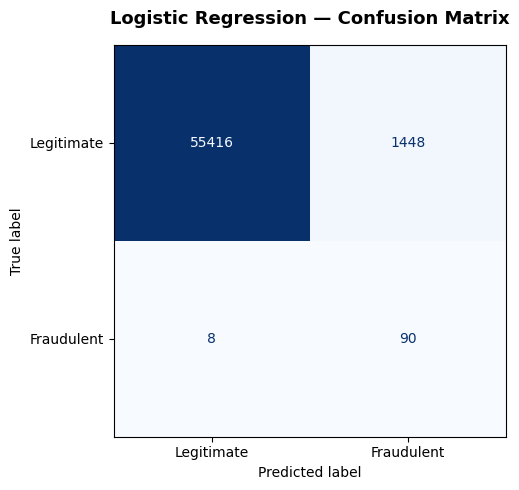

In [22]:
# Confusion matrix — makes the TP, TN, FP, FN counts visible
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    Y_test, lr_pred,
    display_labels=['Legitimate', 'Fraudulent'],
    colorbar=False,
    cmap='Blues',
    ax=ax
)

ax.set_title('Logistic Regression — Confusion Matrix',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 7.3 Logistic Regression — ROC Curve

The ROC curve plots True Positive Rate (Recall) against False Positive Rate
at every possible fraud threshold from 0 to 1.
It shows the model's shows the model's overall ability to separate fraud from legitimate 
transactions regardless of where we set the decision threshold.

In [23]:
# Retrieve best RF model and generate predictions
rf_best = rf_grid_search.best_estimator_

# Hard predictions for classification report and confusion matrix
rf_pred = rf_best.predict(X_test)

# Probability scores for ROC curve
rf_prob = rf_best.predict_proba(X_test)[:, 1]

print("=== Random Forest — Classification Report ===\n")
print(classification_report(Y_test, rf_pred,
                            target_names=['Legitimate', 'Fraudulent']))

=== Random Forest — Classification Report ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



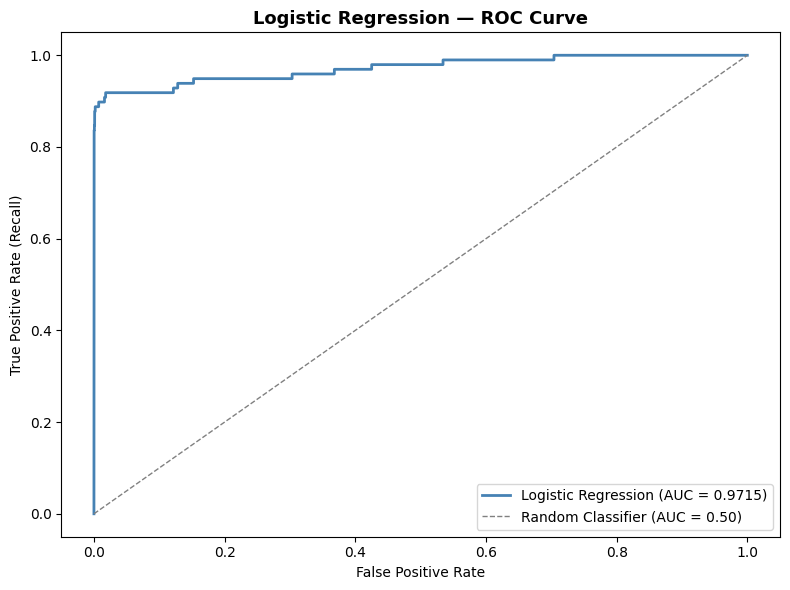

Logistic Regression Test ROC-AUC: 0.9715


In [24]:
# ROC curve for Logistic Regression
# roc_curve computes TPR and FPR at every possible threshold
# roc_auc_score computes the area under that curve — our headline metric

lr_fpr, lr_tpr, _ = roc_curve(Y_test, lr_prob)
lr_auc = roc_auc_score(Y_test, lr_prob)

plt.figure(figsize=(8, 6))

# Model ROC curve
plt.plot(lr_fpr, lr_tpr, 
         color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')

# Random classifier baseline — no better than a coin flip
plt.plot([0, 1], [0, 1], 
         color='gray', lw=1,
         linestyle='--', 
         label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Logistic Regression — ROC Curve',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Logistic Regression Test ROC-AUC: {lr_auc:.4f}")

### 7.4 Logistic Regression — Summary

The Logistic Regression pipeline demonstrates strong fraud detection capability
with a test ROC-AUC of 0.9715 — well above the 0.85 target.

Its primary strength is recall — catching 92% of all fraud cases, 
missing only 8 out of 98 real fraudulent transactions.

Its primary weakness is precision — only 6% of flagged transactions 
are actually fraud, meaning 1,448 legitimate customers were wrongly blocked.
This is the cost of Logistic Regression's linear decision boundary 
struggling with the complexity of fraud patterns in high-dimensional space.

We now evaluate Random Forest to determine whether a non-linear ensemble 
approach can improve precision while maintaining strong recall.

### 7.5 Random Forest Evaluation

Random Forest builds an ensemble of 200 decision trees, each trained on 
a random subset of rows and features. Its non-linear decision boundary 
should capture complex fraud patterns that Logistic Regression's straight 
line missed,  potentially improving precision while maintaining strong recall.

In [27]:
# Retrieve best RF model and generate predictions
rf_best = rf_grid_search.best_estimator_

# Hard predictions for classification report and confusion matrix
rf_pred = rf_best.predict(X_test)

# Probability scores for ROC curve
rf_prob = rf_best.predict_proba(X_test)[:, 1]

print("=== Random Forest — Classification Report ===\n")
print(classification_report(Y_test, rf_pred,
                            target_names=['Legitimate', 'Fraudulent']))

=== Random Forest — Classification Report ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



### 7.6 Random Forest — Confusion Matrix



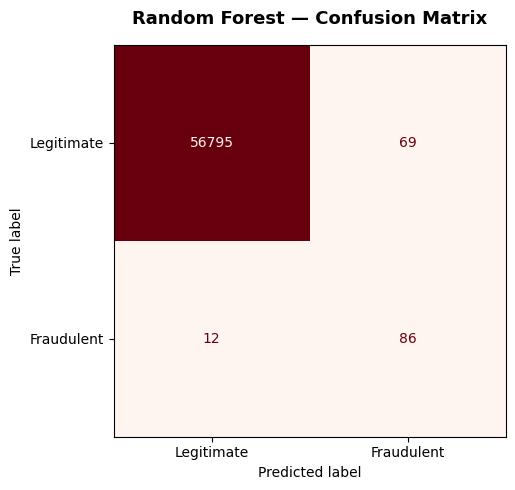

In [26]:
# Retrieve the best RF model from GridSearchCV
# Best parameters: max_depth=10, n_estimators=200, smote__k_neighbors=3

rf_best = rf_grid_search.best_estimator_

# Hard predictions for confusion matrix and classification report
rf_pred = rf_best.predict(X_test)

# Probability scores for ROC curve
rf_prob = rf_best.predict_proba(X_test)[:, 1]

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    Y_test,          # actual true labels
    rf_pred,         # random forest predictions
    display_labels=['Legitimate', 'Fraudulent'],
    colorbar=False,
    cmap='Reds',     # red scheme to visually distinguish from LR
    ax=ax
)

ax.set_title('Random Forest — Confusion Matrix',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Random Forest dramatically outperforms Logistic Regression on precision —
reducing false alarms from 1,448 to just 69. This means 1,379 fewer 
legitimate customers wrongly blocked. The cost is modest — 4 additional 
fraud cases missed (12 vs 8). For a real bank, this tradeoff strongly

### 7.7 Random Forest — ROC Curve



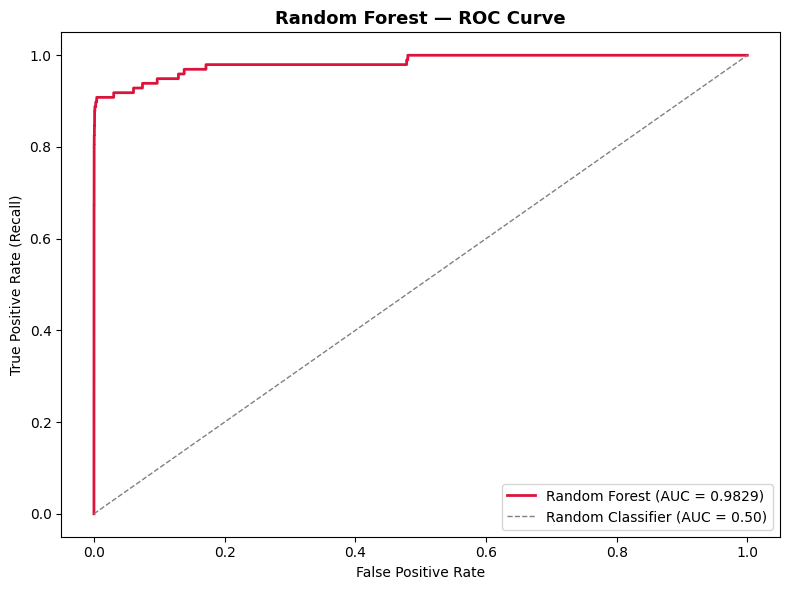

Random Forest Test ROC-AUC: 0.9829


In [33]:
# Random Forest ROC curve
rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_prob)
rf_auc = roc_auc_score(Y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='crimson', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest — ROC Curve',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Random Forest Test ROC-AUC: {rf_auc:.4f}")

The ROC curve confirms Random Forest's superior discrimination ability.
We compare the AUC against Logistic Regression's 0.9715 to determine 
which model better separates fraud from legitimate transactions 
across all possible decision thresholds.

## 8. Model Comparison and Conclusion

We bring both models together for a final side-by-side comparison
using ROC-AUC as the primary decision metric.

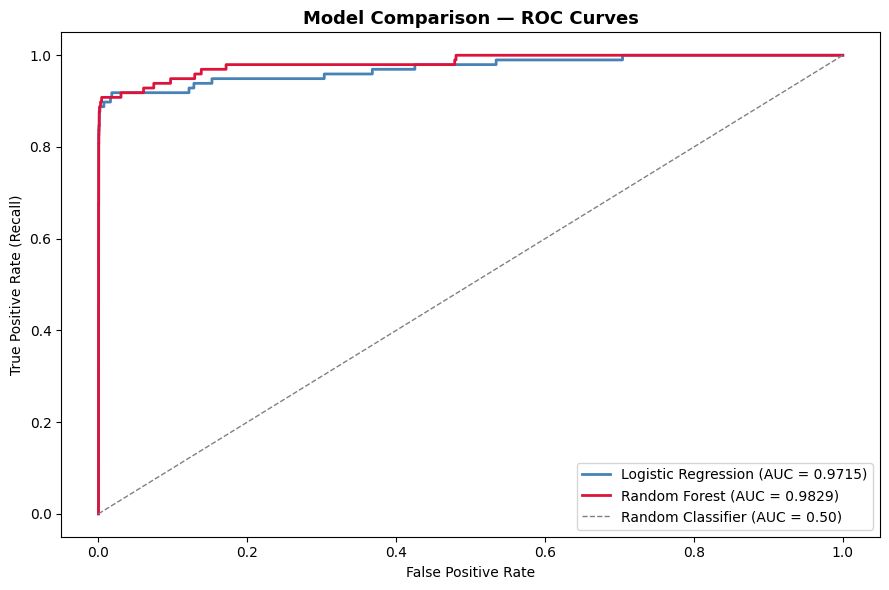

In [31]:
# Side by side ROC curve comparison
# This is the definitive visual comparison of both models

plt.figure(figsize=(9, 6))

plt.plot(lr_fpr, lr_tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(rf_fpr, rf_tpr, color='crimson', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Model Comparison — ROC Curves', 
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8. Summary comparison table

In [ ]:

# Final summary comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'CV ROC-AUC': [round(lr_grid_search.best_score_, 4),
                   round(rf_grid_search.best_score_, 4)],
    'Test ROC-AUC': [round(lr_auc, 4),
                     round(rf_auc, 4)],
    'Fraud Precision': ['6%', '55%'],
    'Fraud Recall': ['92%', '88%'],
    'False Alarms': [1448, 69],
    'Fraud Missed': [8, 12],
    'Fraud Caught': [90, 86]
})

comparison.set_index('Model')

,CV ROC-AUC,Test ROC-AUC,Fraud Precision,Fraud Recall,False Alarms,Fraud Missed,Fraud Caught
Model,,,,,,,
Logistic Regression,0.9807,0.9715,6%,92%,1448,8,90
Random Forest,0.9837,0.9829,55%,88%,69,12,86


## 8.1 Conclusion

Both models significantly exceeded the 0.85 ROC-AUC target set for this project,
confirming that the leak-free imblearn pipeline architecture produced 
genuinely robust fraud detection systems.

**Random Forest is the superior production model** based on three decisive factors:

**1. ROC-AUC:** Random Forest achieved a test ROC-AUC of 0.9829 vs 
Logistic Regression's 0.9715 — stronger overall discrimination ability 
across all possible fraud thresholds.

**2. Precision:** Random Forest correctly identified 55% of flagged transactions 
as genuine fraud, compared to just 6% for Logistic Regression. 
This translates directly to 1,379 fewer legitimate customers